In [44]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import IPythonConsole
from tabs import DihedralInfoFromTorsionLib
from tabs.clustering import ClusterPreparation, ClusterRunner, ClusterAnalyzer
from tabs import custom
import mdtraj as md
import pandas as pd

import matplotlib.pyplot as plt

Getting the molecule.

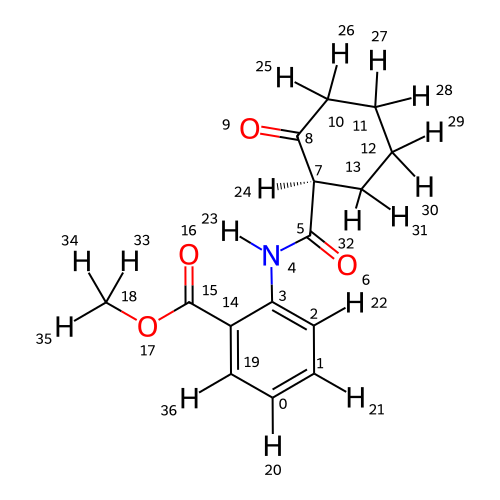

In [45]:
mol = Chem.AddHs(Chem.MolFromSmiles("[H]c1c([H])c([H])c(N([H])C(=O)[C@@]2([H])C(=O)C([H])([H])C([H])([H])C([H])([H])C2([H])[H])c(C(=O)OC([H])([H])[H])c1[H]"))
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 500,500
rdDepictor.SetPreferCoordGen(True)
mol

Constructing the ``DihedralsInfo`` object with the trajectory data.

In [46]:
info = DihedralInfoFromTorsionLib(mol)
traj = md.load("../Data/Tests/traj.h5")
coords = traj.xyz
customProfiles = custom.GetTorsionProfilesFromMDTraj(traj, info.indices)

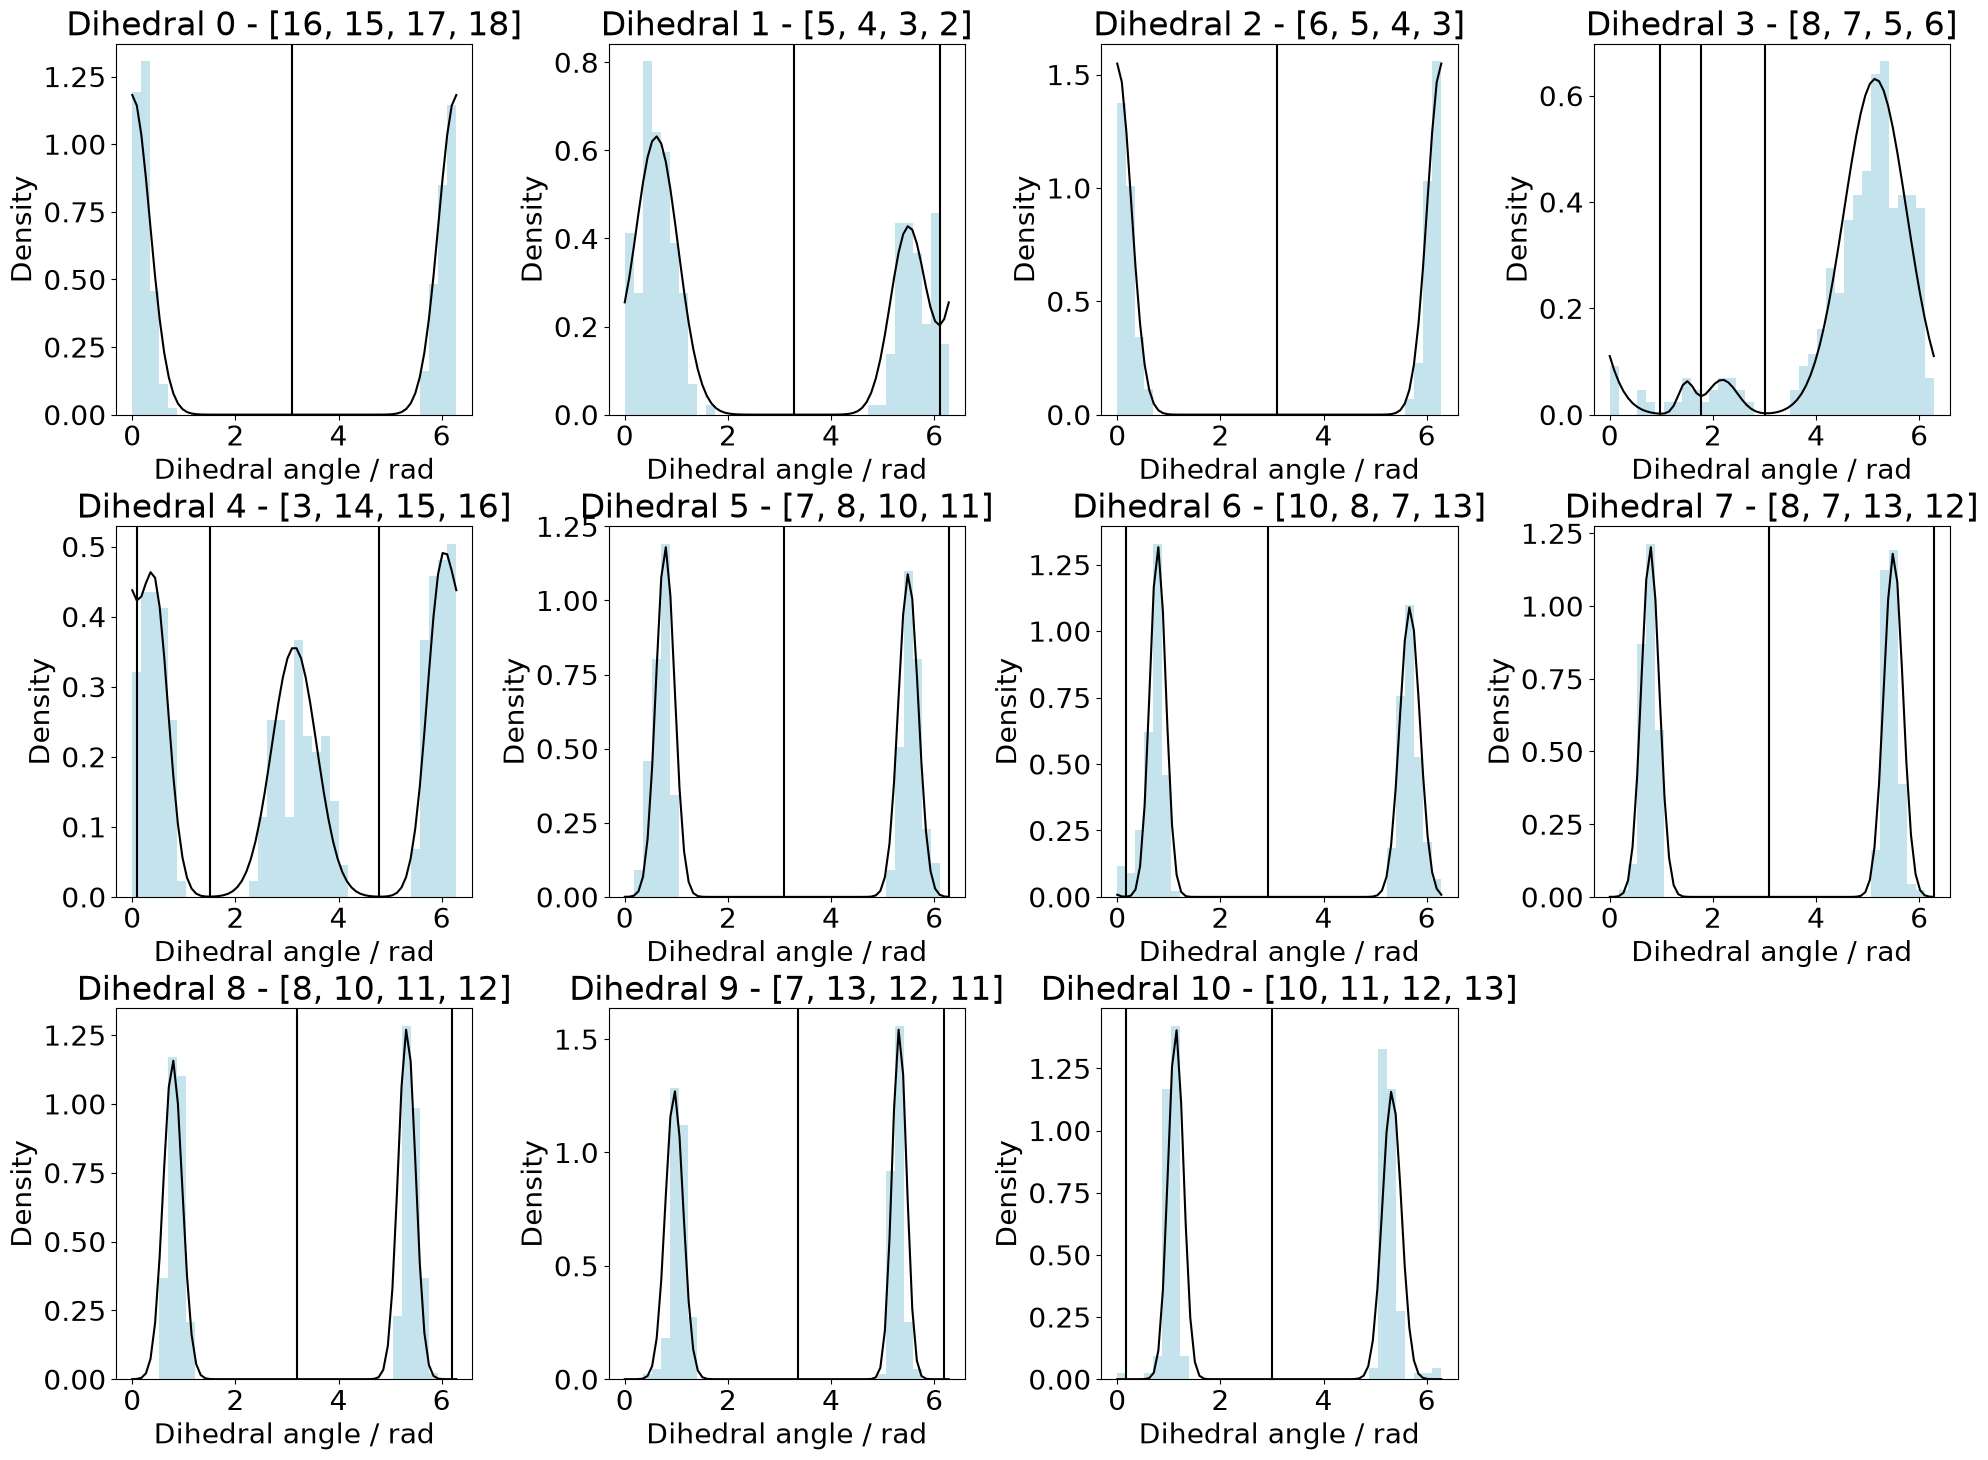

In [47]:
info2 = custom.CustomDihedralInfo(mol, info.indices, customProfiles, showFits=True, excludePeaks=1e-3, prominence=1e-3)

In [48]:
prep = ClusterPreparation(mol, info2, coords, customProfiles)
prep.GetCentroids()

In [49]:
prep.GetDistanceMatrix()
prep.centroidDistances

array([[0.        , 0.59845912, 0.56556266, 0.71272929, 0.43093059,
        0.53141364, 0.40524028, 0.60277614, 1.03514779, 1.02983827,
        1.23492545, 1.09683149, 0.97412639, 1.7067427 , 1.64037463,
        1.84804714, 1.83431947, 0.75840462, 0.91130303, 0.82938257,
        1.11383901, 1.02523912, 1.00205891, 1.09574279, 1.2561684 ,
        1.73169595, 1.68449487],
       [0.59845912, 0.        , 0.61165913, 0.55541501, 0.87528018,
        0.68038766, 0.49502103, 0.49381734, 1.27499203, 1.04362739,
        1.17503691, 1.21182776, 0.89589727, 1.59678578, 1.60268956,
        1.70466653, 1.67595975, 0.80604974, 0.69057384, 0.89890497,
        1.01198246, 1.03638407, 0.96968855, 1.29763369, 1.24373054,
        1.66548597, 1.63126349],
       [0.56556266, 0.61165913, 0.        , 0.8534606 , 0.87696394,
        0.95017099, 0.61328978, 0.72242456, 1.35581669, 1.28455114,
        1.43968211, 1.39152272, 1.09690064, 1.76287795, 1.87183307,
        1.81706948, 1.64467323, 0.62764997, 0.6443

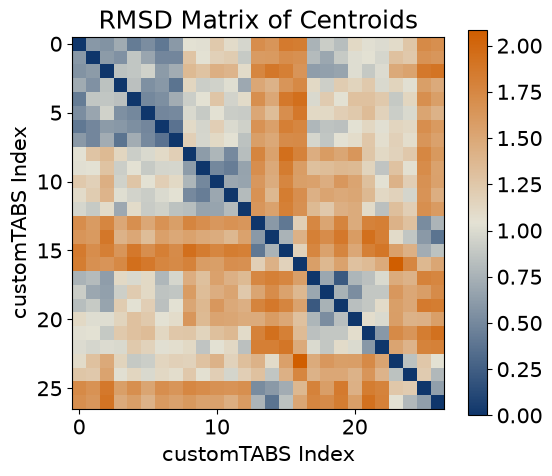

In [50]:
prep.VisualizeDistanceMatrix();

In [51]:
run = ClusterRunner(prep, "maxclust", 4)
run.RunClustering()

In [52]:
run.clustering, run.clusteringDict

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 4, 1, 1, 1, 1, 1,
        1, 3, 3, 2, 2], dtype=int32),
 {1: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 17, 18, 19, 20,
         21, 22]),
  2: array([13, 14, 15, 25, 26]),
  3: array([23, 24]),
  4: array([16])})

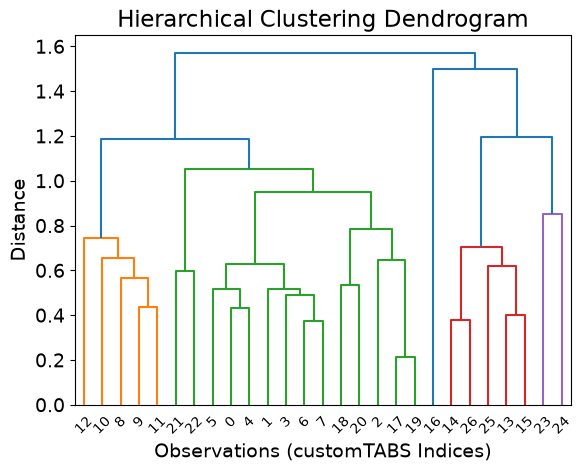

In [53]:
plt.rcParams['font.size'] = 14
run.GetDendrogram(p=30)

In [54]:
analysis = ClusterAnalyzer(run)
analysis.CalculateChiSquared()

In [55]:
# change cramersV to a DataFrame for easier viewing
cramersVDf = pd.DataFrame.from_dict(analysis.cramersV, orient='index', columns=['Cramer\'s V'])
# sort by Cramer's V value
cramersVDf.sort_values(by='Cramer\'s V', ascending=False)

,Cramer's V
"(8, 7, 5, 6)",0.836660
"(10, 8, 7, 13)",0.519571
"(7, 8, 10, 11)",0.443419
"(8, 10, 11, 12)",0.443419
"(5, 4, 3, 2)",0.396736
"(7, 13, 12, 11)",0.354775
"(8, 7, 13, 12)",0.354775
"(10, 11, 12, 13)",0.354775
"(3, 14, 15, 16)",0.333026
"(16, 15, 17, 18)",NaN


In [56]:
for k in range(0,1):
    importancesPerN = dict()
    for dihedral in info2.indices:
        importancesPerN[tuple(dihedral)] = []
    for i in range(1,13):
        run = ClusterRunner(prep, "maxclust", i)
        run.RunClustering()
        analysis = ClusterAnalyzer(run)
        analysis.CalculateChiSquared()
        for dihedral in info2.indices:
            importancesPerN[tuple(dihedral)].append(analysis.cramersV[tuple(dihedral)])

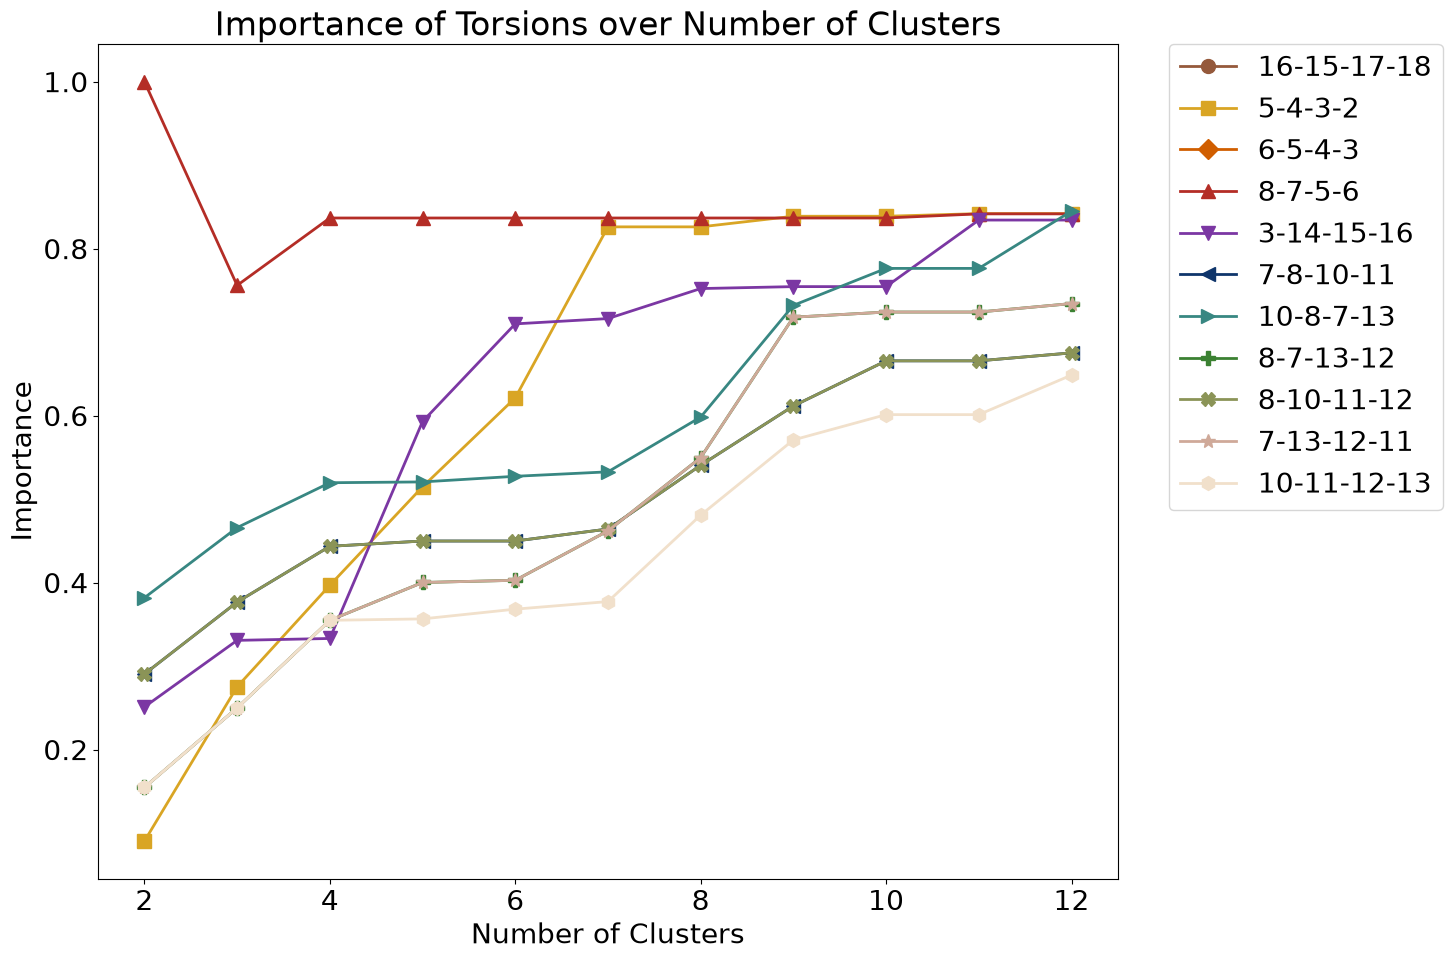

In [57]:
plt.rcParams['font.size'] = 20
fig, ax = plt.subplots(figsize=(15, 10))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X', '*', 'h', 'H']
colors = ["#95593b", "#d9a524", "#d05e00", "#b42d26", "#7b37a3", "#0f356b", "#388782", "#3b8132", "#8b9457", "#cfa999", "#f1e0cb"]

for k, dihedral in enumerate(info2.indices):
    marker = markers[k % len(markers)]  
    color = colors[k % len(colors)]  
    
    ax.plot(range(1, 13),
            importancesPerN[tuple(dihedral)],
            marker=marker,
            color=color,
            label=f"{dihedral[0]}-{dihedral[1]}-{dihedral[2]}-{dihedral[3]}",
            markersize=10,
            linewidth=2)

ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Importance")
ax.set_title("Importance of Torsions over Number of Clusters")

# place legend outside on the right
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)

fig.tight_layout()
plt.show()